**CSI 4106 Introduction to Artificial Intelligence (Fall 2025)** <br/>
*Assignment 3: Alien Pet Health, Deep Learning*

# Identification

Name: Jamie Bly <br/>
Student Number: 300231604

--

## 0. Preamble

In [2]:
# Suggested librairies

import os
from pathlib import Path
import urllib.request
import urllib.error

import random
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

from sklearn.metrics import (
    f1_score, precision_score, recall_score, roc_auc_score
)

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers, callbacks
from keras.metrics import F1Score

In [3]:
URL_DATA = "https://raw.githubusercontent.com/turcotte/csi4106-f25/main/assignments-data/a2/alien_pet_health-realism-clean.csv"

COLS_TO_STANDARDIZE = ["thermoreg_reading", "enzyme_activity_index", "stress_variability"]
COLS_TO_NORMALIZE = ["dual_lobe_signal"]
COLS_TO_ENCODE = ["habitat_zone"]
COLS_NO_PREPROC = ["activity_score","fasting_flag"]
TARGET   = "health_outcome"

COLUMNS_DATA = COLS_TO_STANDARDIZE + COLS_TO_NORMALIZE + COLS_TO_ENCODE + COLS_NO_PREPROC

RANDOM_STATE = 42
TEST_SIZE    = 0.20

SCORING = {
    "precision_macro": "precision_macro",
    "recall_macro": "recall_macro",
    "f1_macro": "f1_macro",
    "roc_auc": "roc_auc",
}

PRIMARY_METRIC = F1Score(threshold=0.5, average="macro")

In [4]:
def load_dataset_or_fail(url=URL_DATA, cache_dir="data", *, verbose=True):

    """
    Load the dataset, downloading it once and caching locally.

    - Extracts the filename from the URL.
    - Stores it under `cache_dir`.
    - Validates required columns and target.

    Returns
    -------
    X : pandas.DataFrame
    y : numpy.ndarray
    """

    cache_dir = Path(cache_dir)
    cache_dir.mkdir(parents=True, exist_ok=True)
    filename = Path(url).name
    cache_path = cache_dir / filename

    # 1) Download if not cached

    if not cache_path.exists():
        if verbose:
            print(f"Downloading dataset from {url} ...")
        try:
            urllib.request.urlretrieve(url, cache_path)
            if verbose:
                print(f"Saved to {cache_path}")
        except (urllib.error.URLError, urllib.error.HTTPError) as e:
            raise RuntimeError(f"Failed to download dataset: {e}")

    # 2) Read the CSV

    try:
        df = pd.read_csv(cache_path)
    except Exception as e:
        raise RuntimeError(f"Failed to read {cache_path}: {e}")

    # 3) Validate content

    if TARGET not in df.columns:
        raise ValueError(f"Missing target column '{TARGET}' in {cache_path}")

    df = df.dropna(subset=[TARGET]).copy()

    missing = set(COLUMNS_DATA).difference(df.columns)
    if missing:
        raise ValueError(f"Missing columns in {cache_path}: {sorted(missing)}")

    # 4) Split features and target

    X = df[COLUMNS_DATA]
    y = df[TARGET].astype(int).to_numpy().reshape(-1,1) # (n,) -> (n,1)

    return X, y

In [5]:
def set_seed(seed: int = 42):
    
    """Fix most randomness sources for reproducible demos."""

    os.environ["PYTHONHASHSEED"] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)

In [6]:
set_seed(42)

# 1. Data

For this assignment, we use a dataset in which all tasks from the prior assignment have been thoroughly completed. Notably, Assignment 3 uses the dataset [alien_pet_health-realism-clean.csv](https://raw.githubusercontent.com/turcotte/csi4106-f25/main/assignments-data/a2/alien_pet_health-realism-clean.csv), from assignment Assignment 2.

## Load the dataset

- Read the CSV file (`alien_pet_health-realism-clean.csv`).
- Show the shape of the data, as well as the first five rows.

In [7]:
# Python code

X, y = load_dataset_or_fail(URL_DATA)
print(X.shape)
print(y.shape)
display(X.describe())
X.head()

(5000, 7)
(5000, 1)


,thermoreg_reading,enzyme_activity_index,stress_variability,dual_lobe_signal,activity_score,fasting_flag
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,50.000140,100.005800,0.000580,2.001180,2.967200,0.401800
std,8.000065,29.989012,5.000697,3.000172,1.290138,0.490311
min,21.000000,0.000000,-18.000000,-6.500000,1.000000,0.000000
25%,44.600000,80.000000,-3.400000,-0.400000,2.000000,0.000000
50%,50.100000,100.000000,0.000000,2.500000,3.000000,0.000000
75%,55.200000,120.000000,3.425000,4.500000,4.000000,1.000000
max,77.800000,231.000000,18.700000,8.900000,5.000000,1.000000


,thermoreg_reading,enzyme_activity_index,stress_variability,dual_lobe_signal,habitat_zone,activity_score,fasting_flag
0,52.6,97.0,-3.5,3.6,c2,2,0
1,41.8,105.0,10.5,3.4,c1,2,0
2,56.2,126.0,9.6,5.5,c2,5,0
3,57.7,106.0,-4.0,-4.1,c1,4,0
4,34.5,73.0,0.3,2.3,c4,5,1


## Data splitting

- Split the dataset into training (70%), validation (15%) and test (15%) sets.
- Ensure that this split occurs before any preprocessing to avoid data leakage.

In [8]:
# Python code

X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=TEST_SIZE, stratify=y, random_state=RANDOM_STATE)

X_val, X_test, y_val, y_test   = train_test_split(X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=RANDOM_STATE)


## Data Pre-Processing

In [9]:
# Python code

def make_preprocessor(COLS_TO_STANDARDIZE, COLS_TO_NORMALIZE, COLS_TO_ENCODE, COLS_NO_PREPROC):

    """
    Build a ColumnTransformer for the Alien Pet Health dataset.

    - Standardizes selected columns (zero mean, unit variance)
    - Normalizes selected columns to [0,1]
    - One-hot encodes categorical columns
    - Passes specified columns through unchanged

    Note: Columns in COLS_NO_PREPROC must already be numeric (e.g., 0/1 flags).
    """

    preprocessor = ColumnTransformer(
        transformers=[
            ("standardize", StandardScaler(), COLS_TO_STANDARDIZE),
            ("normalize", MinMaxScaler(), COLS_TO_NORMALIZE),
            ("encode", OneHotEncoder(handle_unknown="ignore", sparse_output=False), COLS_TO_ENCODE),
            ("keep", "passthrough", COLS_NO_PREPROC),
        ],
        remainder="drop",
        verbose_feature_names_out=False,
    )

    return preprocessor

def fit_transform_inputs(preprocess: ColumnTransformer, X_train: pd.DataFrame, 
                         X_val: pd.DataFrame, X_test: pd.DataFrame):

    """
    Fit the preprocessor on train; transform train/val/test consistently.
    Returns numpy arrays and input_dim for Keras.
    """

    Xtr = preprocess.fit_transform(X_train)
    Xva = preprocess.transform(X_val)
    Xte = preprocess.transform(X_test)
    input_dim = Xtr.shape[1]

    return Xtr, Xva, Xte, input_dim

In [10]:
# Python code

preprocess = make_preprocessor(COLS_TO_STANDARDIZE, COLS_TO_NORMALIZE, COLS_TO_ENCODE, COLS_NO_PREPROC)

Xtr, Xva, Xte, input_dim = fit_transform_inputs(preprocess, X_train, X_val, X_test)

# 2. Tasks

The tasks are arranged in a specific order to optimize brevity and clarity. Although you have some flexibility in organizing your code, it is important that your teaching assistant can effortlessly identify the code segments related to each task.

Suggestions: Start with a small model (e.g., 8 units) and train for 10–20 epochs using default hyperparameters. Expand exploration only after observing reasonable learning curves and metrics. Create reusable helper functions and consistently plot training and validation loss curves. Log experiments concisely, plotting loss curves only for the best model for each task.

In [11]:
# Python code

def create_compile_fit_plot(model, eps):

    model.compile(loss="binary_crossentropy",
              optimizer="Adam",
              metrics=["accuracy"])

    history = model.fit(Xtr, y_train, epochs=eps,
                    validation_data=(Xva, y_val))

    pd.DataFrame(history.history).plot(
        figsize=(8, 5), xlim=[0, eps], ylim=[0, 1], grid=True, xlabel="Epoch",
        style=["r--", "r--.", "b-", "b-*"])
    plt.legend(loc="lower left")  # extra code  
    plt.show()

def create_compile_fit_plot_callback(model, eps, early_stop):
    model.compile(loss="binary_crossentropy",
              optimizer="Adam",
              metrics=["accuracy", "f1_score"])

    history = model.fit(Xtr, y_train, epochs=eps,
                    validation_data=(Xva, y_val),
                    callbacks=[early_stop])

    pd.DataFrame(history.history).plot(
        figsize=(8, 5), xlim=[0, eps], ylim=[0, 1], grid=True, xlabel="Epoch",
        style=["r--", "r--.", "b-", "b-*"])
    plt.legend(loc="lower left")  # extra code  
    plt.show()


## Build a Simple Feed-Forward Network

Regarding the question of whether this models overfits or underfits the data, this model actually shows that it is neither overfitting or underfitting at the size.

The training and validation data follows closely with each other, while also converging to a similar lower value. 

This indicates that the model is fitting well to the data.


Epoch 1/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.5393 - loss: 0.8188 - val_accuracy: 0.5720 - val_loss: 0.7156
Epoch 2/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6122 - loss: 0.6814 - val_accuracy: 0.6360 - val_loss: 0.6540
Epoch 3/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6687 - loss: 0.6327 - val_accuracy: 0.6880 - val_loss: 0.6082
Epoch 4/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7063 - loss: 0.5903 - val_accuracy: 0.7140 - val_loss: 0.5695
Epoch 5/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7385 - loss: 0.5538 - val_accuracy: 0.7500 - val_loss: 0.5366
Epoch 6/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7607 - loss: 0.5225 - val_accuracy: 0.7680 - val_loss: 0.5077
Epoch 7/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7772 - loss: 0.4954 - val_accuracy: 0.7820 - val_loss: 0.4824
Epoch 8/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7878 - loss: 0.4722 - val_accuracy: 0

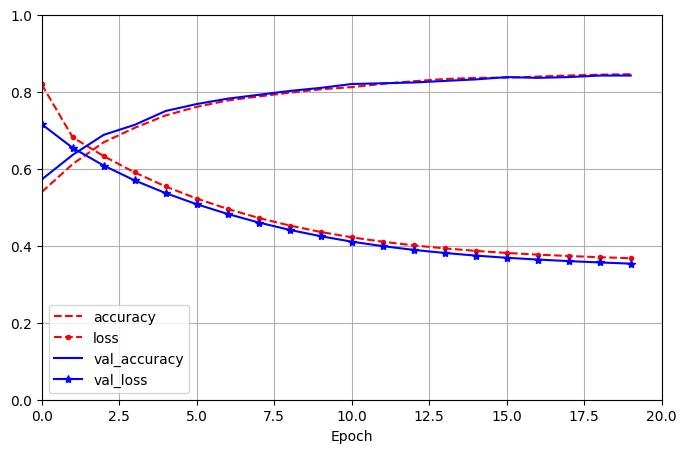

Epoch 1/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.5045 - loss: 0.8372 - val_accuracy: 0.4980 - val_loss: 0.7253
Epoch 2/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5495 - loss: 0.6925 - val_accuracy: 0.5540 - val_loss: 0.6662
Epoch 3/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6220 - loss: 0.6521 - val_accuracy: 0.6360 - val_loss: 0.6334
Epoch 4/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6820 - loss: 0.6222 - val_accuracy: 0.7100 - val_loss: 0.6040
Epoch 5/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7125 - loss: 0.5955 - val_accuracy: 0.7500 - val_loss: 0.5781
Epoch 6/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7300 - loss: 0.5718 - val_accuracy: 0.7540 - val_loss: 0.5560
Epoch 7/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7458 - loss: 0.5516 - val_accuracy: 0.7780 - val_loss: 0.5374
Epoch 8/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7595 - loss: 0.5345 - val_accu

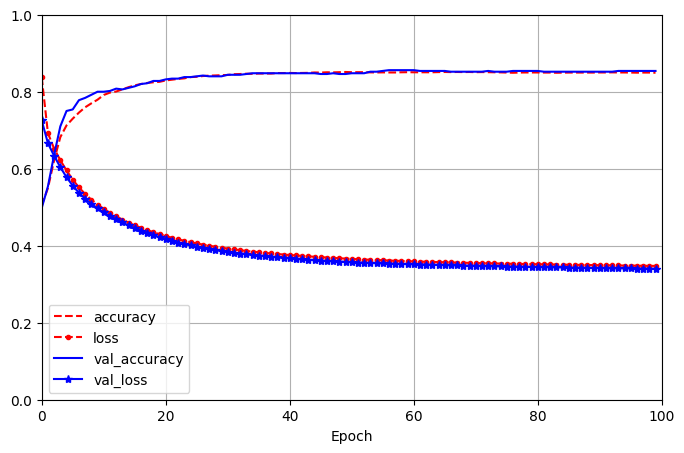

In [12]:
# Python code
def create_new_model():
    tf.keras.backend.clear_session()
    tf.random.set_seed(42)

    model = keras.Sequential()

    model.add(tf.keras.layers.Input(shape=(input_dim,)))
    model.add(tf.keras.layers.Flatten())
    model.add(tf.keras.layers.Dense(units=8, activation="relu"))
    model.add(tf.keras.layers.Dense(1, activation="sigmoid"))
    return model

model = create_new_model()
create_compile_fit_plot(model, 20)
model_100eps = create_new_model()
create_compile_fit_plot(model_100eps, 100)

## Overfitting

### Describe the approach used to achieve overfitting in the model.

In order to make this overfit, there were 3 major points that I focused on, as was described in our lectures.

1) Avoiding using features like L2 weight penalties, dropout, and early stopping (as mentioned in lectures and assignment) that help to avoid overfitting.
2) While avoiding using features that would help regulate the model, I also made sure to 
    1) Make the model unnecessarily complex with multiple layers with too many units
    2) Having the model run for too many epochs/iterations

### Explain the evidence that indicates the model is overfitting.

The evidence that indicates overfitting is quite evident in this model. 

Even at a first glance at the resulting graph, you can see that while loss and val_loss have a similar pattern to begin with, as the epochs continue, the val_loss begins to diverge from loss, as it begins to increase whereas loss continues decreasing steadily.

This is a clear indication of overfitting, as it indicates that the model is learning the data and noise, which results in the training data showing good results but the validation data failing.

There is also a less obvious, but still relevant divergence from the accuracy of the model after the 10th epoch, with the accuracy_val staying relatively static and the accuracy continuing to show improvement.

To make this even more evident, lets compare the 10th Epoch and the 50th epoch (from my current run):

10th : accuracy: 0.8820 - loss: 0.2565 - val_accuracy: 0.8880 - val_loss: 0.2438
50th : accuracy: 0.9448 - loss: 0.1257 - val_accuracy: 0.8780 - val_loss: 0.4708

The difference between val_loss and loss after the 10th epcoh was |0.0127| and the differnce after the 50th epoch was |0.3451|, which is a significant difference and only becomes more so with a larger number of epochs (when running for 100 epochs, val_loss was actually greater than 1.0 at points).

The same point made above for loss VS val_loss can be made for accuracy and val_accuracy.



Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 11)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1000)           │        12,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 500)            │       500,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 80)             │        40,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1000)           │        81,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 100)            │       100,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         1,010 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 734,701 (2.80 MB)

 Trainable params: 734,701 (2.80 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.7960 - loss: 0.4347 - val_accuracy: 0.8580 - val_loss: 0.3406
Epoch 2/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8420 - loss: 0.3508 - val_accuracy: 0.8560 - val_loss: 0.3255
Epoch 3/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8525 - loss: 0.3326 - val_accuracy: 0.8600 - val_loss: 0.2889
Epoch 4/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8630 - loss: 0.3127 - val_accuracy: 0.8720 - val_loss: 0.2667
Epoch 5/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8698 - loss: 0.2948 - val_accuracy: 0.8740 - val_loss: 0.2588
Epoch 6/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8748 - loss: 0.2831 - val_accuracy: 0.8840 - val_loss: 0.2526
Epoch 7/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8795 - loss: 0.2714 - val_accuracy: 0.8740 - val_loss: 0.2544
Epoch 8/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8790 - loss: 0.2667 - val_accuracy: 0.

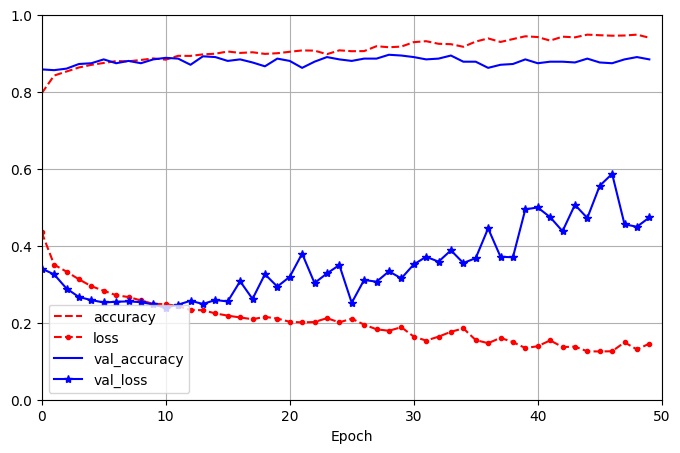

In [13]:
# Python code
tf.keras.backend.clear_session()
tf.random.set_seed(42)

model_over = keras.Sequential([
    tf.keras.layers.Input(shape=(input_dim,)),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(units=1000, activation="relu"),
    tf.keras.layers.Dense(units=500, activation="relu"),
    tf.keras.layers.Dense(units=80, activation="relu"),
    tf.keras.layers.Dense(units=1000, activation="relu"),
    tf.keras.layers.Dense(units=100, activation="relu"),
    tf.keras.layers.Dense(units=10, activation="relu"),
    tf.keras.layers.Dense(1, activation="sigmoid")
])

model_over.summary()

create_compile_fit_plot(model_over, 50)


## Eearly Stopping

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 11)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1000)           │        12,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 500)            │       500,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 80)             │        40,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1000)           │        81,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 100)            │       100,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         1,010 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 734,701 (2.80 MB)

 Trainable params: 734,701 (2.80 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.7983 - f1_score: 0.6664 - loss: 0.4343 - val_accuracy: 0.8580 - val_f1_score: 0.6667 - val_loss: 0.3427
Epoch 2/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8447 - f1_score: 0.6664 - loss: 0.3438 - val_accuracy: 0.8600 - val_f1_score: 0.6667 - val_loss: 0.3330
Epoch 3/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8543 - f1_score: 0.6664 - loss: 0.3254 - val_accuracy: 0.8620 - val_f1_score: 0.6667 - val_loss: 0.2872
Epoch 4/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8662 - f1_score: 0.6668 - loss: 0.3085 - val_accuracy: 0.8760 - val_f1_score: 0.6667 - val_loss: 0.2705
Epoch 5/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8630 - f1_score: 0.6669 - loss: 0.2948 - val_accuracy: 0.8800 - val_f1_score: 0.6667 - val_loss: 0.2577
Epoch 6/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8735 - f1_score: 0.6674 - loss: 0.2762 - val_accuracy: 0.8740 - val_f1_score: 0.6676

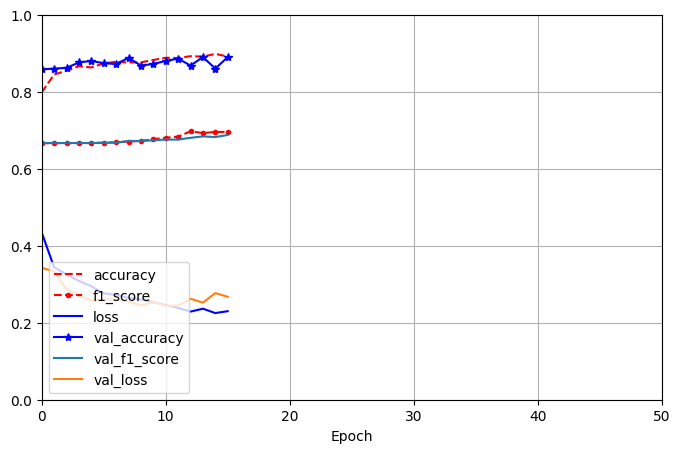

16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
Precision Score: 0.8327
Recall Score: 0.896
AUC/ROC: 0.858


In [14]:
# Python code
early_stop = tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        min_delta=0.001,
        patience=5,
        verbose=1,
        mode="min",
        baseline=None,
        restore_best_weights=True,
        start_from_epoch=0
)

tf.keras.backend.clear_session()
tf.random.set_seed(42)

model_es = keras.Sequential([
    tf.keras.layers.Input(shape=(input_dim,)),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(units=1000, activation="relu"),
    tf.keras.layers.Dense(units=500, activation="relu"),
    tf.keras.layers.Dense(units=80, activation="relu"),
    tf.keras.layers.Dense(units=1000, activation="relu"),
    tf.keras.layers.Dense(units=100, activation="relu"),
    tf.keras.layers.Dense(units=10, activation="relu"),
    tf.keras.layers.Dense(1, activation="sigmoid")
])

model_es.summary()

create_compile_fit_plot_callback(model_es, 50, early_stop)

model_es_y_preds = model_es.predict(Xte)
model_es_y_preds_threshold = np.where(model_es_y_preds > 0.5, 1,0)


print("Precision Score: " + str(round(precision_score(y_test, model_es_y_preds_threshold),4)))
print("Recall Score: " + str(round(recall_score(y_test, model_es_y_preds_threshold),4)))
print("AUC/ROC: " + str(round(roc_auc_score(y_test, model_es_y_preds_threshold),4)))


## Architecture Exploration

### Does the model underfit or overfit? How can you tell?

For my observations, the best configuration of the model doesnèt overfit or underfit, and is a good generalization of the model.

Looking at the results and graph produced by running the found "Best_Config", you can see that the loss and val_loss do not diverge and follow a very similar line. This is simialr to the result of the first section.

### My Observations

1) It appears that 16 or 32 units are the best number of units for this model if the goal is higher recall, as there is a spike in results for recall at those numbers, whereas there is a general pattern of 64 being generally better for precision, f1_score and ROC/AUC score.
2) I can see a slight pattern of relu being more linear and consistent than tanh, though there is not enough evidence of this for me to definitively come to a conclusion.


Epoch 1/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - f1_score: 0.6664 - loss: 0.6663 - val_f1_score: 0.6667 - val_loss: 0.6343
Epoch 2/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - f1_score: 0.6664 - loss: 0.6180 - val_f1_score: 0.6667 - val_loss: 0.5785
Epoch 3/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - f1_score: 0.6664 - loss: 0.5620 - val_f1_score: 0.6667 - val_loss: 0.5245
Epoch 4/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - f1_score: 0.6664 - loss: 0.5103 - val_f1_score: 0.6667 - val_loss: 0.4784
Epoch 5/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - f1_score: 0.6664 - loss: 0.4675 - val_f1_score: 0.6667 - val_loss: 0.4427
Epoch 6/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - f1_score: 0.6664 - loss: 0.4366 - val_f1_score: 0.6667 - val_loss: 0.4177
Epoch 7/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - f1_score: 0.6664 - loss: 0.4153 - val_f1_score: 0.6667 - val_loss: 0.4010
Epoch 8/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - f1_score: 0.6664 - loss: 0.4006 - val_f1_score: 0.

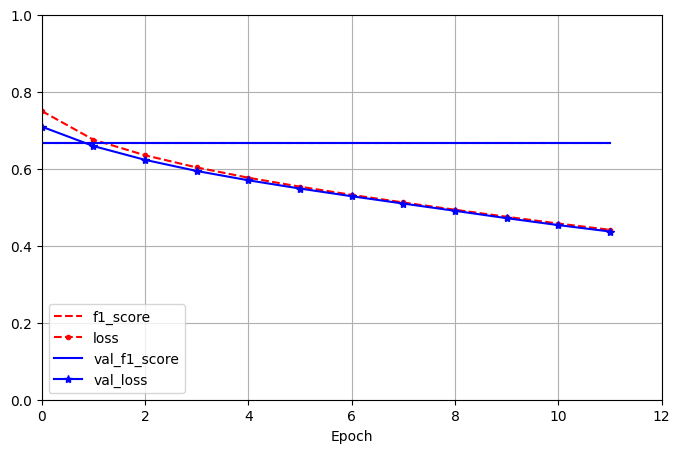

In [17]:
# Python code
def create_model_spec_callback(EPS, UNITS, HIDDEN_LAYERS, ACTIVATIONS):

    early_stop = tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        min_delta=0.01,
        patience=2,
        verbose=1,
        mode="min",
        baseline=None,
        restore_best_weights=True,
        start_from_epoch=0
    )

    tf.keras.backend.clear_session()
    tf.random.set_seed(42)

    exp_model = keras.Sequential([ ])  
    exp_model.add(tf.keras.layers.Input(shape=(input_dim,)))
    exp_model.add(tf.keras.layers.Flatten())
    count =0
    while count < HIDDEN_LAYERS:
        exp_model.add(tf.keras.layers.Dense(units=UNITS, activation=ACTIVATIONS))
        count+=1
    exp_model.add(tf.keras.layers.Dense(1, activation="sigmoid")) 
    
    exp_model.compile(loss="binary_crossentropy",
              optimizer="Adam",
              metrics=[tf.keras.metrics.F1Score()])

    exp_model.fit(Xtr, y_train, epochs=EPS,
                    validation_data=(Xva, y_val),
                    callbacks=[early_stop])
    
    exp_model_preds = exp_model.predict(Xte)
    exp_model_preds = np.where(exp_model_preds > 0.5, 1,0)


    return[str(UNITS) + " - " + str(HIDDEN_LAYERS) + " - " + ACTIVATIONS, str(round(precision_score(y_test, exp_model_preds),4)), str(round(recall_score(y_test, exp_model_preds),4)), str(round(roc_auc_score(y_test, exp_model_preds),4)), str(round(f1_score(y_test, exp_model_preds),4))]
    
model_results = []
best_config = []
best_config_results = []


for hidden_layer in [1,2,3]:
    for activation in ['relu', "tanh"]:
        for units in [8, 16, 32, 64]:
            current_model_results = create_model_spec_callback(50, units, hidden_layer, activation)
            model_results.append(current_model_results)
            counter=0
            if best_config == []:
                best_config = [units, hidden_layer, activation]
                best_config_results = current_model_results
            else:
                for item in [1,2,3,4]:
                    if float(current_model_results[item]) > float(best_config_results[item]):
                        counter+=1
                if counter > 2:
                    best_config_results = current_model_results
          

early_stop = tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        min_delta=0.01,
        patience=5,
        verbose=1,
        mode="min",
        baseline=None,
        restore_best_weights=False,
        start_from_epoch=0
)

df_model = pd.DataFrame(model_results, columns=["Units - Hidden layers - activation","precision_score", "recall_score", "roc_auc_score", "f1_score"])
print(df_model)
print(best_config)
print(best_config_results)

tf.keras.backend.clear_session()
tf.random.set_seed(42)

exp_model = keras.Sequential([ ])  
exp_model.add(tf.keras.layers.Input(shape=(input_dim,)))
exp_model.add(tf.keras.layers.Flatten())
count =0
while count < best_config[1]:
    exp_model.add(tf.keras.layers.Dense(units=best_config[0], activation=best_config[2]))
    count+=1
exp_model.add(tf.keras.layers.Dense(1, activation="sigmoid")) 

exp_model.compile(loss="binary_crossentropy",
            optimizer="Adam",
            metrics=["f1_score"])

history = exp_model.fit(Xtr, y_train, epochs=12,
                validation_data=(Xva, y_val),
                callbacks=[early_stop])

pd.DataFrame(history.history).plot(
    figsize=(8, 5), xlim=[0, 12], ylim=[0, 1], grid=True, xlabel="Epoch",
    style=["r--", "r--.", "b-", "b-*"])
plt.legend(loc="lower left")  # extra code  
plt.show()




## Regularization

For this section, I am going to use 64 - 2 - tanh as the configuration, as it was the quickest of the last section to require an early stop, which should lead  to this overfitting without it 

Running without L2 Penalty
Epoch 1/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - f1_score: 0.6664 - loss: 0.5059 - val_f1_score: 0.6667 - val_loss: 0.3701
Epoch 2/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - f1_score: 0.6664 - loss: 0.3593 - val_f1_score: 0.6667 - val_loss: 0.3257
Epoch 3/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - f1_score: 0.6664 - loss: 0.3349 - val_f1_score: 0.6667 - val_loss: 0.3069
Epoch 4/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - f1_score: 0.6664 - loss: 0.3170 - val_f1_score: 0.6667 - val_loss: 0.2916
Epoch 5/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - f1_score: 0.6664 - loss: 0.3026 - val_f1_score: 0.6667 - val_loss: 0.2795
Epoch 6/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - f1_score: 0.6664 - loss: 0.2930 - val_f1_score: 0.6667 - val_loss: 0.2718
Epoch 7/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - f1_score: 0.6664 - loss: 0.2856 - val_f1_score: 0.6667 - val_loss: 0.2670
Epoch 8/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - f1_score: 0.666

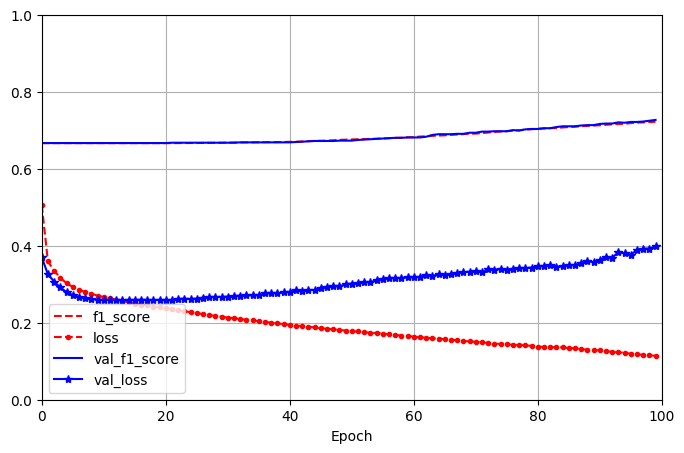

16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
Running WITH L2 Penalty
Regularizer: 0.001
Epoch 1/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - f1_score: 0.6664 - loss: 0.6214 - val_f1_score: 0.6667 - val_loss: 0.4652
Epoch 2/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - f1_score: 0.6664 - loss: 0.4486 - val_f1_score: 0.6667 - val_loss: 0.4062
Epoch 3/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - f1_score: 0.6664 - loss: 0.4123 - val_f1_score: 0.6667 - val_loss: 0.3774
Epoch 4/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - f1_score: 0.6664 - loss: 0.3891 - val_f1_score: 0.6667 - val_loss: 0.3582
Epoch 5/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - f1_score: 0.6664 - loss: 0.3741 - val_f1_score: 0.6667 - val_loss: 0.3477
Epoch 6/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - f1_score: 0.6664 - loss: 0.3635 - val_f1_score: 0.6667 - val_loss: 0.3411
Epoch 7/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - f1_score: 0.6664 - loss: 0.3560 - val_f1_score: 0.6667 - val_loss: 0.3349
Epoch 8/100
125

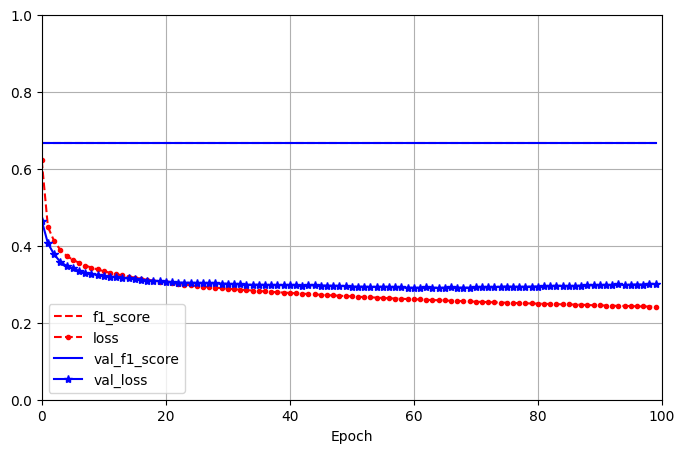

16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
Regularizer: 0.0001
Epoch 1/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - f1_score: 0.6664 - loss: 0.5280 - val_f1_score: 0.6667 - val_loss: 0.3821
Epoch 2/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - f1_score: 0.6664 - loss: 0.3730 - val_f1_score: 0.6667 - val_loss: 0.3293
Epoch 3/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - f1_score: 0.6664 - loss: 0.3454 - val_f1_score: 0.6667 - val_loss: 0.3055
Epoch 4/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - f1_score: 0.6664 - loss: 0.3274 - val_f1_score: 0.6667 - val_loss: 0.2918
Epoch 5/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - f1_score: 0.6664 - loss: 0.3151 - val_f1_score: 0.6667 - val_loss: 0.2837
Epoch 6/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - f1_score: 0.6664 - loss: 0.3058 - val_f1_score: 0.6667 - val_loss: 0.2775
Epoch 7/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - f1_score: 0.6664 - loss: 0.2992 - val_f1_score: 0.6667 - val_loss: 0.2750
Epoch 8/100
125/125 ━━━━━━━━━━━━━━━━━━

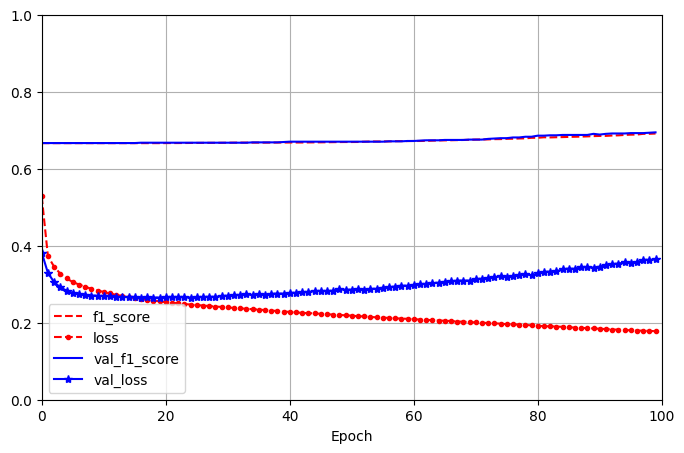

16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
Testing Drop out
Drop out : 0.25
Epoch 1/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - f1_score: 0.6664 - loss: 0.6538 - val_f1_score: 0.6667 - val_loss: 0.5496
Epoch 2/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - f1_score: 0.6664 - loss: 0.5824 - val_f1_score: 0.6667 - val_loss: 0.4616
Epoch 3/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - f1_score: 0.6664 - loss: 0.5534 - val_f1_score: 0.6667 - val_loss: 0.4276
Epoch 4/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - f1_score: 0.6664 - loss: 0.5258 - val_f1_score: 0.6667 - val_loss: 0.4092
Epoch 5/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - f1_score: 0.6664 - loss: 0.5345 - val_f1_score: 0.6667 - val_loss: 0.4115
Epoch 6/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - f1_score: 0.6664 - loss: 0.5108 - val_f1_score: 0.6667 - val_loss: 0.3883
Epoch 7/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - f1_score: 0.6664 - loss: 0.5125 - val_f1_score: 0.6667 - val_loss: 0.3887
Epoch 8/100
125/125 ━━━━━

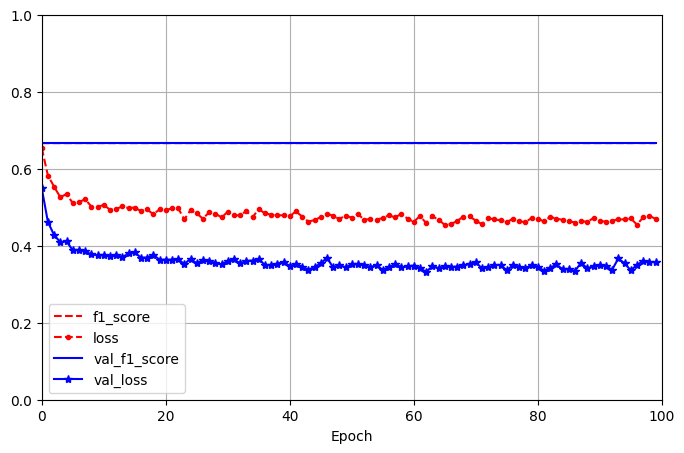

16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
Drop out: 0.5
Epoch 1/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - f1_score: 0.6664 - loss: 0.7849 - val_f1_score: 0.6667 - val_loss: 0.6792
Epoch 2/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - f1_score: 0.6664 - loss: 0.7093 - val_f1_score: 0.6667 - val_loss: 0.6777
Epoch 3/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - f1_score: 0.6664 - loss: 0.6902 - val_f1_score: 0.6667 - val_loss: 0.6688
Epoch 4/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - f1_score: 0.6664 - loss: 0.6827 - val_f1_score: 0.6667 - val_loss: 0.6547
Epoch 5/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - f1_score: 0.6664 - loss: 0.6722 - val_f1_score: 0.6667 - val_loss: 0.6414
Epoch 6/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - f1_score: 0.6664 - loss: 0.6628 - val_f1_score: 0.6667 - val_loss: 0.6365
Epoch 7/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - f1_score: 0.6664 - loss: 0.6433 - val_f1_score: 0.6667 - val_loss: 0.6128
Epoch 8/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 

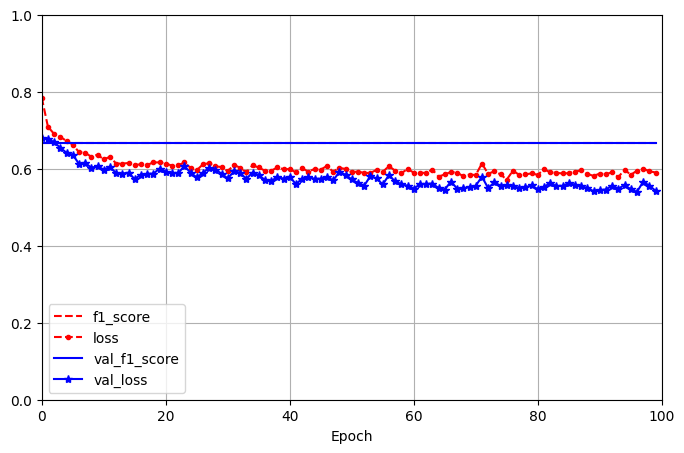

16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
        Regularization precision_score recall_score roc_auc_score f1_score
0        No Regulation          0.8248        0.904         0.856   0.8626
1            l2: 0.001          0.8358        0.896          0.86   0.8649
2           l2: 0.0001          0.8382        0.912         0.868   0.8736
3  Drop out rate: 0.25          0.7958         0.92         0.842   0.8534
4   Drop out rate: 0.5          0.7897        0.856         0.814   0.8215


In [ ]:
# Python code
#Question 1: L2 Penalty

print("Running without L2 Penalty")
tf.keras.backend.clear_session()
tf.random.set_seed(42)

nonreg_model = keras.Sequential([ ])  
nonreg_model.add(tf.keras.layers.Input(shape=(input_dim,)))
nonreg_model.add(tf.keras.layers.Flatten())
nonreg_model.add(tf.keras.layers.Dense(units=64, activation="relu"))
nonreg_model.add(tf.keras.layers.Dense(units=64, activation="relu"))
nonreg_model.add(tf.keras.layers.Dense(units=64, activation="relu"))
nonreg_model.add(tf.keras.layers.Dense(1, activation="sigmoid")) 

nonreg_model.compile(loss="binary_crossentropy",
            optimizer="Adam",
            metrics=["f1_score"])

history = nonreg_model.fit(Xtr, y_train, epochs=100,
                validation_data=(Xva, y_val))

pd.DataFrame(history.history).plot(
    figsize=(8, 5), xlim=[0, 100], ylim=[0, 1], grid=True, xlabel="Epoch",
    style=["r--", "r--.", "b-", "b-*"])
plt.legend(loc="lower left")  # extra code  
plt.show()

nonreg_model_preds = nonreg_model.predict(Xte)
nonreg_model_preds = np.where(nonreg_model_preds > 0.5, 1,0)

results = [["No Regulation", str(round(precision_score(y_test, nonreg_model_preds),4)), str(round(recall_score(y_test, nonreg_model_preds),4)), str(round(roc_auc_score(y_test, nonreg_model_preds),4)), str(round(f1_score(y_test, nonreg_model_preds),4))]]

print("Running WITH L2 Penalty")
two_z_regularizer = tf.keras.regularizers.l2(0.001)
three_z_regularizer = tf.keras.regularizers.l2(0.0001)
tf.keras.backend.clear_session()
tf.random.set_seed(42)

print("Regularizer: 0.001")
reg_model = keras.Sequential([ ])  
reg_model.add(tf.keras.layers.Input(shape=(input_dim,)))
reg_model.add(tf.keras.layers.Flatten())
reg_model.add(tf.keras.layers.Dense(units=64, activation="relu", kernel_regularizer=two_z_regularizer))
reg_model.add(tf.keras.layers.Dense(units=64, activation="relu", kernel_regularizer=two_z_regularizer))
reg_model.add(tf.keras.layers.Dense(units=64, activation="relu", kernel_regularizer=two_z_regularizer))
reg_model.add(tf.keras.layers.Dense(1, activation="sigmoid")) 

reg_model.compile(loss="binary_crossentropy",
            optimizer="Adam",
            metrics=["f1_score"])

history = reg_model.fit(Xtr, y_train, epochs=100,
                validation_data=(Xva, y_val))

pd.DataFrame(history.history).plot(
    figsize=(8, 5), xlim=[0, 100], ylim=[0, 1], grid=True, xlabel="Epoch",
    style=["r--", "r--.", "b-", "b-*"])
plt.legend(loc="lower left")  # extra code  
plt.show()

reg_model_preds = reg_model.predict(Xte)
reg_model_preds = np.where(reg_model_preds > 0.5, 1,0)

results.append(["l2: 0.001", str(round(precision_score(y_test, reg_model_preds),4)), str(round(recall_score(y_test, reg_model_preds),4)), str(round(roc_auc_score(y_test, reg_model_preds),4)), str(round(f1_score(y_test, reg_model_preds),4))])

tf.keras.backend.clear_session()
tf.random.set_seed(42)

print("Regularizer: 0.0001")
reg_model = keras.Sequential([ ])  
reg_model.add(tf.keras.layers.Input(shape=(input_dim,)))
reg_model.add(tf.keras.layers.Flatten())
reg_model.add(tf.keras.layers.Dense(units=64, activation="relu", kernel_regularizer=three_z_regularizer))
reg_model.add(tf.keras.layers.Dense(units=64, activation="relu", kernel_regularizer=three_z_regularizer))
reg_model.add(tf.keras.layers.Dense(units=64, activation="relu", kernel_regularizer=three_z_regularizer))
reg_model.add(tf.keras.layers.Dense(1, activation="sigmoid")) 

reg_model.compile(loss="binary_crossentropy",
            optimizer="Adam",
            metrics=["f1_score"])

history = reg_model.fit(Xtr, y_train, epochs=100,
                validation_data=(Xva, y_val))

pd.DataFrame(history.history).plot(
    figsize=(8, 5), xlim=[0, 100], ylim=[0, 1], grid=True, xlabel="Epoch",
    style=["r--", "r--.", "b-", "b-*"])
plt.legend(loc="lower left")  # extra code  
plt.show()

reg_model_preds = reg_model.predict(Xte)
reg_model_preds = np.where(reg_model_preds > 0.5, 1,0)

results.append(["l2: 0.0001", str(round(precision_score(y_test, reg_model_preds),4)), str(round(recall_score(y_test, reg_model_preds),4)), str(round(roc_auc_score(y_test, reg_model_preds),4)), str(round(f1_score(y_test, reg_model_preds),4))])


print("Testing Drop out")

tf.keras.backend.clear_session()
tf.random.set_seed(42)

print("Drop out : 0.25")
reg_model = keras.Sequential([ ])  
reg_model.add(tf.keras.layers.Input(shape=(input_dim,)))
reg_model.add(tf.keras.layers.Flatten())
reg_model.add(tf.keras.layers.Dropout(rate=0.25))
reg_model.add(tf.keras.layers.Dense(units=64, activation="relu"))
reg_model.add(tf.keras.layers.Dropout(rate=0.25))
reg_model.add(tf.keras.layers.Dense(units=64, activation="relu"))
reg_model.add(tf.keras.layers.Dropout(rate=0.25))
reg_model.add(tf.keras.layers.Dense(units=64, activation="relu"))
reg_model.add(tf.keras.layers.Dropout(rate=0.25))
reg_model.add(tf.keras.layers.Dense(1, activation="sigmoid")) 

reg_model.compile(loss="binary_crossentropy",
            optimizer="Adam",
            metrics=["f1_score"])

history = reg_model.fit(Xtr, y_train, epochs=100,
                validation_data=(Xva, y_val))

pd.DataFrame(history.history).plot(
    figsize=(8, 5), xlim=[0, 100], ylim=[0, 1], grid=True, xlabel="Epoch",
    style=["r--", "r--.", "b-", "b-*"])
plt.legend(loc="lower left")  # extra code  
plt.show()

reg_model_preds = reg_model.predict(Xte)
reg_model_preds = np.where(reg_model_preds > 0.5, 1,0)

results.append(["Drop out rate: 0.25", str(round(precision_score(y_test, reg_model_preds),4)), str(round(recall_score(y_test, reg_model_preds),4)), str(round(roc_auc_score(y_test, reg_model_preds),4)), str(round(f1_score(y_test, reg_model_preds),4))])

tf.keras.backend.clear_session()
tf.random.set_seed(42)

print("Drop out: 0.5")
reg_model = keras.Sequential([ ])  
reg_model.add(tf.keras.layers.Input(shape=(input_dim,)))
reg_model.add(tf.keras.layers.Flatten())
reg_model.add(tf.keras.layers.Dropout(rate=0.5))
reg_model.add(tf.keras.layers.Dense(units=64, activation="relu"))
reg_model.add(tf.keras.layers.Dropout(rate=0.5))
reg_model.add(tf.keras.layers.Dense(units=64, activation="relu"))
reg_model.add(tf.keras.layers.Dropout(rate=0.5))
reg_model.add(tf.keras.layers.Dense(units=64, activation="relu"))
reg_model.add(tf.keras.layers.Dropout(rate=0.5))
reg_model.add(tf.keras.layers.Dense(1, activation="sigmoid")) 

reg_model.compile(loss="binary_crossentropy",
            optimizer="Adam",
            metrics=["f1_score"])

history = reg_model.fit(Xtr, y_train, epochs=100,
                validation_data=(Xva, y_val))

pd.DataFrame(history.history).plot(
    figsize=(8, 5), xlim=[0, 100], ylim=[0, 1], grid=True, xlabel="Epoch",
    style=["r--", "r--.", "b-", "b-*"])
plt.legend(loc="lower left")  # extra code  
plt.show()

reg_model_preds = reg_model.predict(Xte)
reg_model_preds = np.where(reg_model_preds > 0.5, 1,0)

results.append(["Drop out rate: 0.5", str(round(precision_score(y_test, reg_model_preds),4)), str(round(recall_score(y_test, reg_model_preds),4)), str(round(roc_auc_score(y_test, reg_model_preds),4)), str(round(f1_score(y_test, reg_model_preds),4))])

df_reg_model = pd.DataFrame(results, columns=["Regularization","precision_score", "recall_score", "roc_auc_score", "f1_score"])
print(df_reg_model)


## Model Evaluation

#### This Assignments Results - Precision Score: 0.8545     Recall Score: 0.916       ROC/AUC Score: 0.88      F1 Score: 0.8842
#### Last Assignments Results - Precision Score: 0.85       Recall Score: 0.85        ROC/AUC Score: N/A       F1 Score: 0.85   

In regard to whether there has be any substantial improvement between this assignment and the last, as you can see above, there has evidently been an improvement between the previous model and the current.

All three metrics that were a part of both assignments either show improvement, with the recall score espeically showing great improvement at an increase of almost 7%, or remain at a similar score in the case of the precision score of the model.

#### Observations

1) After adding l2 regularization, I was able to increase the number of units that I use in each hidden layer from 32 to 128, which helped to increase the test performance and minimize loss
2) Though adding dropout on as simple a model as I have used is not ideal and causes issues with higher loss, when I test in the optional section, I hope to significatly increase the hidden_layers and units, and add dropout to see if I can't improve the model more
3) Adding l2 regularization also allowed for more epochs without triggering the early_stop callback that stops overfitting, which helped hone the model.
4) For this model, the higher the dropout rate the worse the result, Though there is also a correlation between a smaller dropout rate increasing the recall score

The technique that is most effective at mitigating overfitting is the L2 regularization, which points to an issue with this model/dataset being the weights of each neuron. Though I believe that using both techniques in the scenario will have excellent results, since the main issue with the dropout is the increased loss, which would be mitigated by the L2 regularization.

After testing in the next section with both techniques and a more complex model, I found the results have an average of 1% increase in all categories except for recall which remained relatively the smae, which proves my above hypothesis.


The best model from my previous tests was [8, 1, 'relu']
Epoch 1/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.5984 - precision: 0.7778 - recall: 0.7949 - val_loss: 0.4457 - val_precision: 0.8346 - val_recall: 0.8880
Epoch 2/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.4359 - precision: 0.8377 - recall: 0.8519 - val_loss: 0.3955 - val_precision: 0.8496 - val_recall: 0.9040
Epoch 3/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.4053 - precision: 0.8469 - recall: 0.8634 - val_loss: 0.3740 - val_precision: 0.8396 - val_recall: 0.9000
Epoch 4/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.3860 - precision: 0.8523 - recall: 0.8689 - val_loss: 0.3574 - val_precision: 0.8433 - val_recall: 0.9040
Epoch 5/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.3711 - precision: 0.8574 - recall: 0.8784 - val_loss: 0.3447 - val_precision: 0.8459 - val_recall: 0.9000
Epoch 6/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.3595 - precision: 0.8587 - recall: 

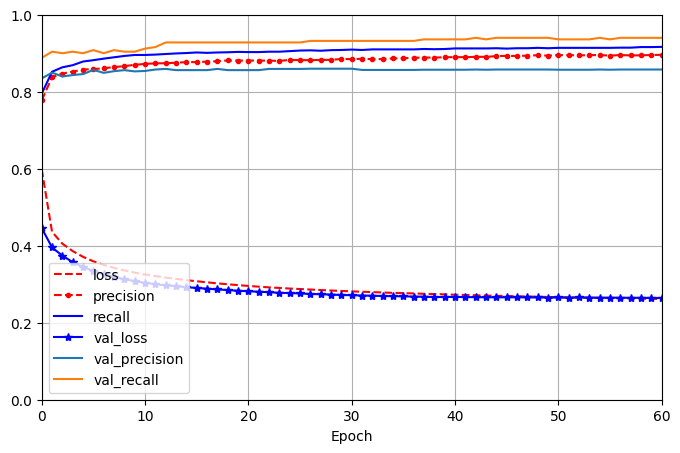

16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
['Precision Score: 0.8545', 'Recall Score: 0.916', 'ROC/AUC Score: 0.88', 'F1 Score: 0.8842']


In [ ]:
# Python code
tf.keras.backend.clear_session()
tf.random.set_seed(42)

print("The best model from my previous tests was " + str(best_config))
best_model = keras.Sequential([ ])  
best_model.add(tf.keras.layers.Input(shape=(input_dim,)))
best_model.add(tf.keras.layers.Flatten())
best_model.add(tf.keras.layers.Dense(units=128, activation="relu", kernel_regularizer=two_z_regularizer))
best_model.add(tf.keras.layers.Dense(units=128, activation="relu", kernel_regularizer=two_z_regularizer))
best_model.add(tf.keras.layers.Dense(1, activation="sigmoid")) 

best_early_stop = tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        min_delta=0.0001,
        patience=5,
        verbose=1,
        mode="min",
        baseline=None,
        restore_best_weights=False,
        start_from_epoch=0
)

best_model.compile(loss="binary_crossentropy",
            optimizer="Adam",
            metrics=["precision", "recall"])

history = best_model.fit(Xtr, y_train, epochs=100,
                validation_data=(Xva, y_val),
                callbacks=[best_early_stop])

pd.DataFrame(history.history).plot(
    figsize=(8, 5), xlim=[0, 60], ylim=[0, 1], grid=True, xlabel="Epoch",
    style=["r--", "r--.", "b-", "b-*"])
plt.legend(loc="lower left")  # extra code  
plt.show()

best_model_preds = best_model.predict(Xte)
best_model_preds = np.where(best_model_preds > 0.5, 1,0)

best_results = (["Precision Score: "+ str(round(precision_score(y_test, best_model_preds),4)), "Recall Score: "+ str(round(recall_score(y_test, best_model_preds),4)), "ROC/AUC Score: "+str(round(roc_auc_score(y_test, best_model_preds),4)), "F1 Score: "+str(round(f1_score(y_test, best_model_preds),4))])

print(str(best_results))

## Bonus - further improvements

Epoch 1/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - loss: 0.7244 - precision: 0.6856 - recall: 0.6873 - val_loss: 0.5012 - val_precision: 0.7902 - val_recall: 0.9040
Epoch 2/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.5269 - precision: 0.8036 - recall: 0.8434 - val_loss: 0.4236 - val_precision: 0.8429 - val_recall: 0.8800
Epoch 3/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.4798 - precision: 0.8237 - recall: 0.8509 - val_loss: 0.4043 - val_precision: 0.8370 - val_recall: 0.9040
Epoch 4/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.4464 - precision: 0.8358 - recall: 0.8404 - val_loss: 0.3810 - val_precision: 0.8675 - val_recall: 0.8640
Epoch 5/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.4334 - precision: 0.8387 - recall: 0.8529 - val_loss: 0.3688 - val_precision: 0.8485 - val_recall: 0.8960
Epoch 6/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.4118 - precision: 0.8447 - recall: 0.8569 - val_loss: 0.3568 - val_precision: 0.8528 - val_r

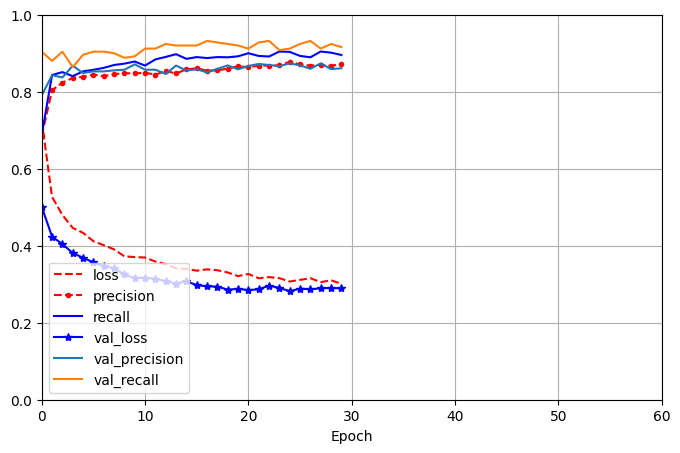

16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
['Precision Score: 0.8707', 'Recall Score: 0.916', 'ROC/AUC Score: 0.89', 'F1 Score: 0.8928']


In [147]:
# Python code

tf.keras.backend.clear_session()
tf.random.set_seed(42)

improved_model = keras.Sequential([ ])  
improved_model.add(tf.keras.layers.Input(shape=(input_dim,)))
improved_model.add(tf.keras.layers.Flatten())
improved_model.add(tf.keras.layers.Dense(units=128, activation="relu", kernel_regularizer=two_z_regularizer))
improved_model.add(tf.keras.layers.Dropout(rate=0.3))
improved_model.add(tf.keras.layers.Dense(units=128, activation="relu", kernel_regularizer=three_z_regularizer))
improved_model.add(tf.keras.layers.Dropout(rate=0.25))
improved_model.add(tf.keras.layers.Dense(units=128, activation="relu", kernel_regularizer=three_z_regularizer))
improved_model.add(tf.keras.layers.Dropout(rate=0.2))
improved_model.add(tf.keras.layers.Dense(units=128, activation="relu", kernel_regularizer=three_z_regularizer))
improved_model.add(tf.keras.layers.Dropout(rate=0.2))
improved_model.add(tf.keras.layers.Dense(units=128, activation="relu", kernel_regularizer=two_z_regularizer))
#improved_model.add(tf.keras.layers.Dropout(rate=0.1))
#improved_model.add(tf.keras.layers.Dense(units=128, activation="relu", kernel_regularizer=three_z_regularizer))
improved_model.add(tf.keras.layers.Dense(1, activation="sigmoid")) 

best_early_stop = tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        min_delta=0.0001,
        patience=5,
        verbose=1,
        mode="min",
        baseline=None,
        restore_best_weights=False,
        start_from_epoch=0
)

improved_model.compile(loss="binary_crossentropy",
            optimizer="Adam",
            metrics=["precision", "recall"])

history = improved_model.fit(Xtr, y_train, epochs=100,
                validation_data=(Xva, y_val),
                callbacks=[best_early_stop])

pd.DataFrame(history.history).plot(
    figsize=(8, 5), xlim=[0, 60], ylim=[0, 1], grid=True, xlabel="Epoch",
    style=["r--", "r--.", "b-", "b-*"])
plt.legend(loc="lower left")  # extra code  
plt.show()

improved_model_preds = improved_model.predict(Xte)
improved_model_preds = np.where(improved_model_preds > 0.5, 1,0)

best_results = (["Precision Score: "+ str(round(precision_score(y_test, improved_model_preds),4)), "Recall Score: "+ str(round(recall_score(y_test, improved_model_preds),4)), "ROC/AUC Score: "+str(round(roc_auc_score(y_test, improved_model_preds),4)), "F1 Score: "+str(round(f1_score(y_test, improved_model_preds),4))])

print(str(best_results))

# References

https://keras.io/

https://www.w3schools.com/python/

https://stackoverflow.com/


# Resources

ChatGPT 5
https://chatgpt.com/share/6910eb2f-a220-8012-97bb-8dd826770fd9



If you use AI assistance, it is essential to meticulously document all interactions. Your report should specify the tools and their versions, accompanied by a complete transcript of these interactions. Most AI platforms automatically log conversations, so it is advisable to initiate a new conversation specifically for the assignment and consistently use this thread throughout your work. Ensure that this conversation remains focused exclusively on the assignment. Include the transcript of this conversation 